# Imports

In [17]:
from os import listdir

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

%matplotlib inline

# Problem 2

In [18]:
def create_circular_edgelist(N, I):
    edge_list = []
    for u in range(N):
        for v in range(N):
            for i in I:
                if v == (u + i) % N: edge_list.append((u, v))
    return edge_list


## (a)

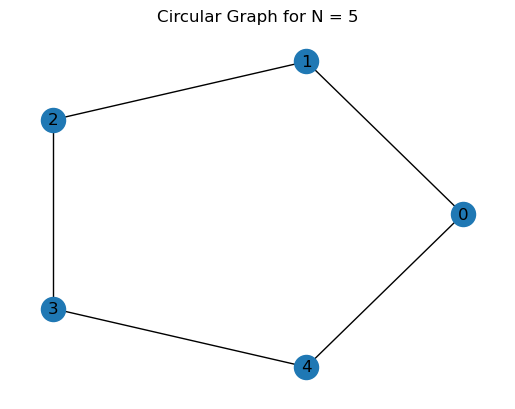

In [19]:
N = 5
I = [1]
G = nx.Graph(create_circular_edgelist(N, I))

fig = plt.figure()
plt.title(f'Circular Graph for N = {N}')
pos = nx.circular_layout(G)
nx.draw_circular(G)
nx.draw_networkx_labels(G, pos)
plt.show()

## (b)

In [20]:
# Using analytic expression prodivded in lecture
analytic_predictions = np.array([2*(1 - np.cos(2*np.pi*k/N)) for k in range(N)])
# Numerically calculating laplacian eigenvalues
laplacian_eig = nx.laplacian_spectrum(G)

print(f"Analytic Predictions:   {np.array2string(np.sort(analytic_predictions), precision=5)}")
print(f"Numerical Calculations: {np.array2string(laplacian_eig, precision=5, suppress_small=True)}")


Analytic Predictions:   [0.      1.38197 1.38197 3.61803 3.61803]
Numerical Calculations: [0.      1.38197 1.38197 3.61803 3.61803]


## (c)

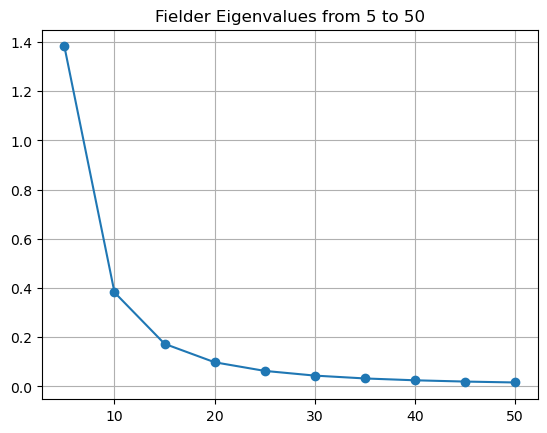

In [21]:
# Looping through N for Fielder eigenvalue
start = 5
stop = 50
step = 5
N = np.arange(start, stop+step, step)

fielder_values = [nx.algebraic_connectivity(nx.Graph(create_circular_edgelist(n, I))) for n in N]

fig = plt.figure()
plt.plot(N, fielder_values, '-o')
plt.title('Fielder Eigenvalues from 5 to 50')
plt.grid()
plt.show()

## (d)

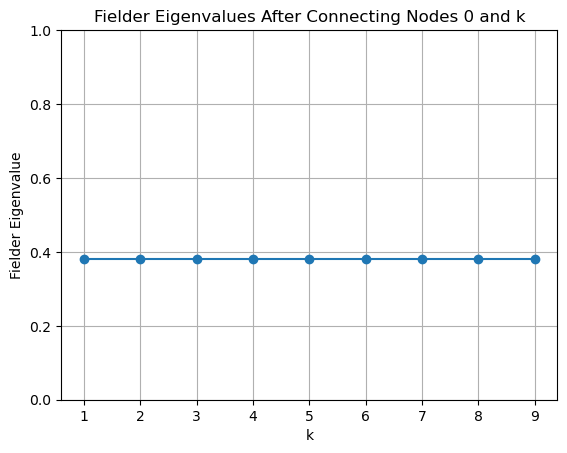

In [22]:
N = 10
G = nx.Graph(create_circular_edgelist(N, I))

fielder_eigenvalues = [None for n in range(1, N)]

for n in range(N-1):
    # Node to be connected
    u = n + 1
    # Checking to see if the edge already exists
    # If the edge exists, connectivity will not change, so fielder eigenvalue remains unchanged
    if G.has_edge(0, u):
        fielder_eigenvalues[n] = nx.algebraic_connectivity(G)
    
    # If the edge does not already exist, create it, analyze, and delete it
    else:
        G.add_edge(0, u)
        fielder_eigenvalues[n] = nx.algebraic_connectivity(G)
        G.remove_edge(0, u)
        
# Plotting results        
fig = plt.figure()
plt.plot(range(1, N), fielder_eigenvalues, '-o')
plt.title('Fielder Eigenvalues After Connecting Nodes 0 and k')
plt.xlabel('k')
plt.ylabel('Fielder Eigenvalue')
plt.grid()
plt.autoscale(False, axis = 'y')
plt.show()


# Problem 3

In [23]:
def spectral_clustering(G: nx.Graph, K: int, normalized = False):
    L = nx.normalized_laplacian_matrix(G).toarray() if normalized else nx.laplacian_matrix(G).toarray()
    
    # Using eigh because L is supposed to be symmetric
    eigvals, eigvecs = np.linalg.eigh(L)

    # We will be using K-means on rows of K_least_vectors
    K_least_vectors = eigvecs[:, :K]
    
    K_means = KMeans(n_clusters = K)
    K_means.fit(K_least_vectors)
    labels = K_means.predict(K_least_vectors)
    
    return labels

In [24]:
karate_graph = nx.karate_club_graph()
pos = nx.circular_layout(karate_graph)

## (a)

c:\Users\djd14\miniconda3\envs\eel6878\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


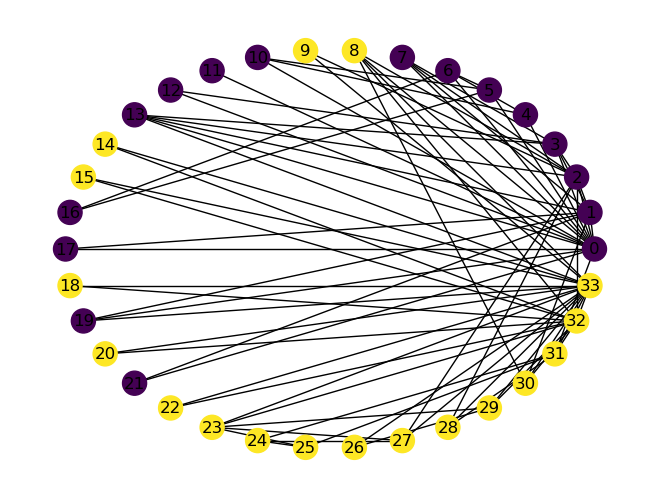

In [25]:
K = 2    
labels = spectral_clustering(karate_graph, K)

fig = plt.figure()
nx.draw(karate_graph, pos, node_color = labels)
nx.draw_networkx_labels(karate_graph, pos)
plt.show()

## (b)

c:\Users\djd14\miniconda3\envs\eel6878\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


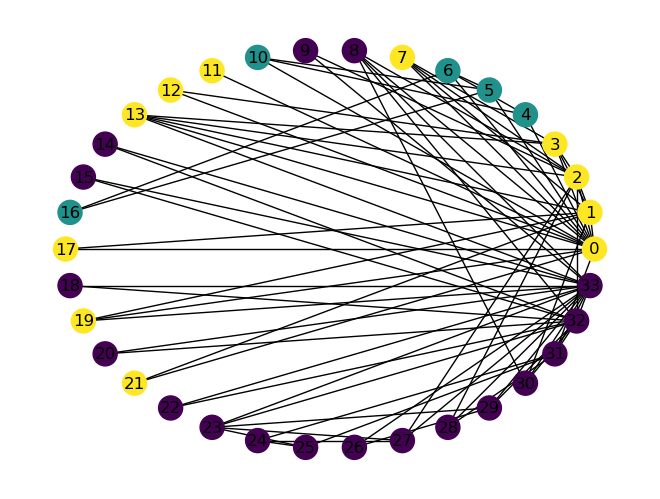

In [26]:
K = 3
labels = spectral_clustering(karate_graph, K)
fig = plt.figure()
nx.draw(karate_graph, pos, node_color = labels)
nx.draw_networkx_labels(karate_graph, pos)
plt.show()

# Problem 4

In [27]:
chars = pd.read_csv("HW2_2026_Harry_Potter_Graph/characters.csv")
edges = pd.read_csv("HW2_2026_Harry_Potter_Graph/relations.csv")

G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row['source'], row['target'], weight = row['weight'], type = row['type'])

In [28]:
node_count = G.number_of_nodes()
edge_count = G.number_of_edges()
average_degree = 2 * edge_count / node_count
density = nx.density(G)
is_connected = nx.is_connected(G)
connected_components = nx.number_connected_components(G)
print(f"Node Count: {node_count}")
print(f"Edge Count: {edge_count}")
print(f"Average Degree: {average_degree}")
print(f"Density = {density}")
print(f"Is Graph Connected: {is_connected}")
print(f"Connected Components: {connected_components}")
print(f"Total Ally Edges: ")
print(f"Total Enemy Edges: ")

Node Count: 65
Edge Count: 317
Average Degree: 9.753846153846155
Density = 0.15240384615384617
Is Graph Connected: True
Connected Components: 1
Total Ally Edges: 
Total Enemy Edges: 


# Problem 5

## (a)

Calculating centralities for each node and storing as dicts for consistency

In [29]:
degree_centrality = dict(G.degree())
weighted_degree_centrality = dict(G.degree(weight = 'weight'))
betweeness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
pagerank = nx.pagerank(G, weight = None)


friend_edge_count = 0
foe_edge_count = 0

for (u, v, d) in G.edges(data = True):
    if d['weight'] < 0: 
        foe_edge_count += 1
        
    elif d['weight'] > 0: 
        friend_edge_count += 1
        
print(f"Ally Edge Count: {friend_edge_count}")
print(f"Enemy Edge Count: {foe_edge_count}")

Ally Edge Count: 211
Enemy Edge Count: 106


Putting centrality calculations in a pandas dataframe

In [30]:
centrality = chars.copy()
# Putting centralities in a dataframe so they area bit easier to view
centrality['Degree']            = centrality['id'].map(degree_centrality)
centrality['Weighted Degree']   = centrality['id'].map(weighted_degree_centrality)
centrality['Betweeness']        = centrality['id'].map(betweeness_centrality)
centrality['Closeness']         = centrality['id'].map(closeness_centrality)
centrality['Eigenvector']       = centrality['id'].map(eigenvector_centrality)
centrality['Pagerank']          = centrality['id'].map(pagerank)

## (b)

Displaying Top 10 of each centrality

In [31]:
centrality_types = ['Degree', 'Weighted Degree', 'Betweeness', 'Closeness', 'Eigenvector', 'Pagerank']

# Looping through each type listed above and using pandas dataframe nlargest to display names and centrality
for centrality_type in centrality_types:
    
    print(centrality_type)
    print('-'*50)
    print(centrality[['id', 'name', centrality_type]].nlargest(10, centrality_type))
    print('-'*50 + '\n')

Degree
--------------------------------------------------
    id              name  Degree
39  39      Harry Potter      46
45  45    Lord Voldemort      36
58  58       Ron Weasley      34
21  21  Hermione Granger      33
11  11  Albus Dumbledore      31
1    1      Sirius Black      21
55  55     Ginny Weasley      18
53  53      Fred Weasley      17
54  54    George Weasley      17
56  56     Molly Weasley      16
--------------------------------------------------

Weighted Degree
--------------------------------------------------
    id                name  Weighted Degree
21  21    Hermione Granger               15
55  55       Ginny Weasley               14
11  11    Albus Dumbledore               13
58  58         Ron Weasley               12
53  53        Fred Weasley               11
54  54      George Weasley               11
57  57       Percy Weasley               11
28  28  Neville Longbottom               10
39  39        Harry Potter               10
50  50      Arthur W

# Problem 6

## (a)

Creating Communities

In [32]:
# Finds communities
communities = nx.community.louvain_communities(G, weight = 'weight')

# Orders communities from largest to smallest
communities = sorted(communities, key = lambda x: len(x), reverse=True)

Community Position on supergraph

In [33]:
supergraph = nx.cycle_graph(len(communities))
# superpos = nx.spring_layout(supergraph, scale = 2, k = 1.5, seed = 2026)
superpos = nx.circular_layout(supergraph, scale = 3)

centers = list(superpos.values())
pos = {}

for center, community in zip(centers, communities):
    # pos.update(nx.spring_layout(nx.subgraph(G, community), scale = 0.7, k = 1.5, center = center, seed = 2026))
    pos.update(nx.circular_layout(nx.subgraph(G, community), center = center, scale = 0.7))


Drawing Plot

c:\Users\djd14\miniconda3\envs\eel6878\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


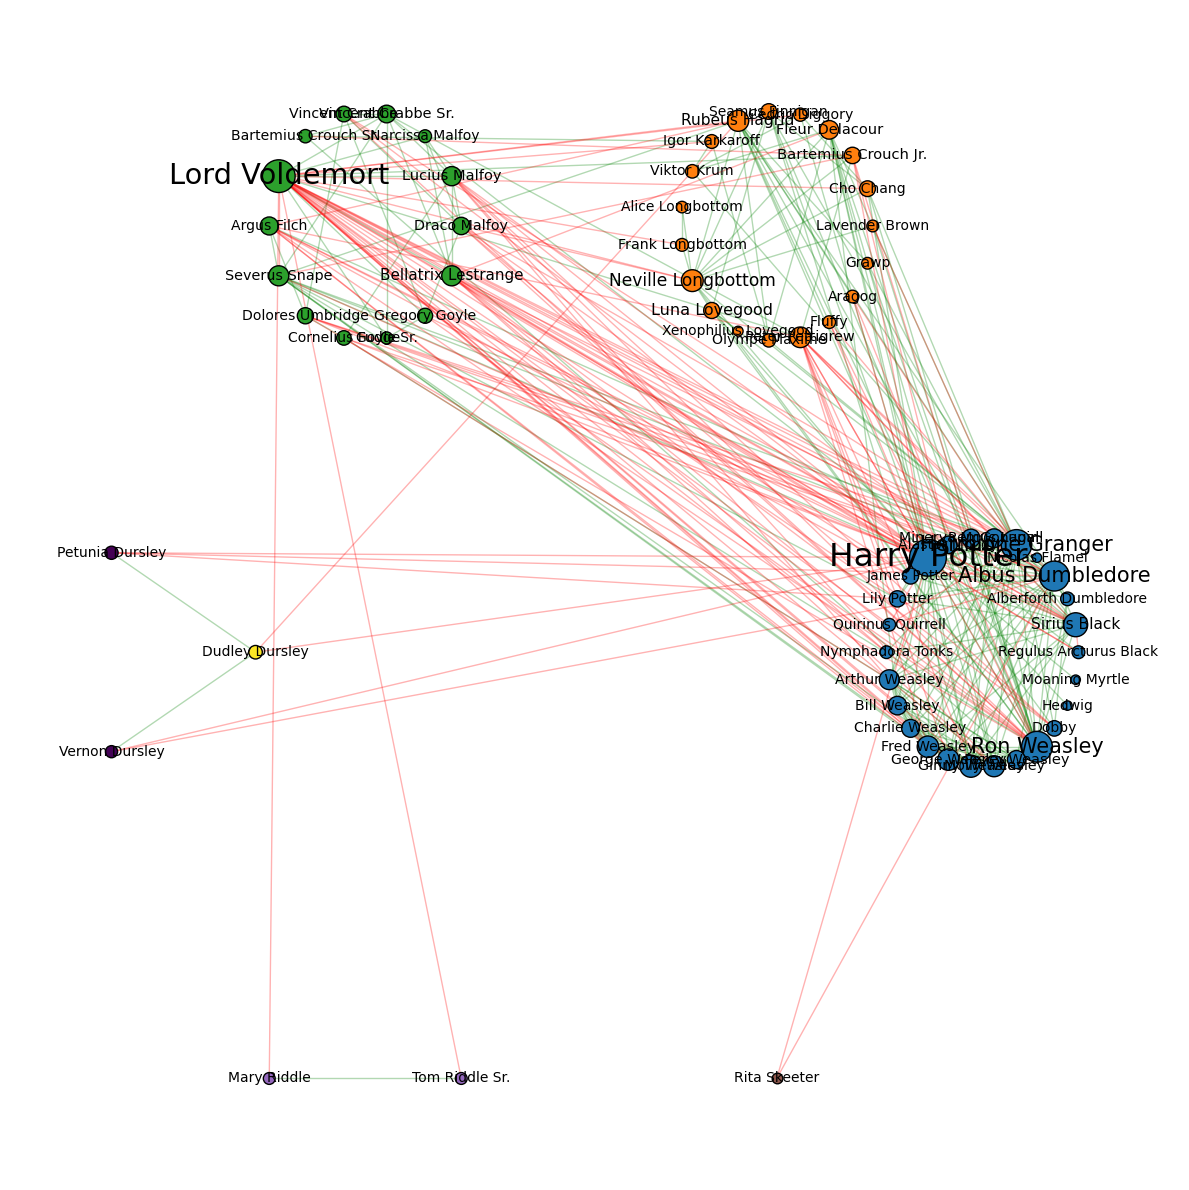

In [34]:

colors = plt.cm.tab10.colors[:9]

fig = plt.figure(figsize = (12, 12))
for nodes, color in zip(communities, colors):
    node_size = 10000*centrality.loc[list(nodes), 'Pagerank'] + 10
    nx.draw_networkx_nodes(G, pos = pos, nodelist = nodes, node_color=color, edgecolors='k', node_size = node_size )

labels = dict(zip(chars['id'], chars['name']))
label_size = dict(zip(centrality['id'], 50*centrality['Betweeness'] + 10))
nx.draw_networkx_labels(G, pos, labels = labels, font_size = label_size)

# Drawing edges green/red based on friend/foe
friend_edges = []
foe_edges = []

for u, v, d in G.edges(data = True):
    if d['weight'] < 0:
        foe_edges.append((u, v))
    elif d['weight'] > 0:
        friend_edges.append((u,v))
        
nx.draw_networkx_edges(G, pos, edgelist = friend_edges, edge_color= 'green', alpha = 0.3)
nx.draw_networkx_edges(G, pos, edgelist = foe_edges, edge_color= 'red', alpha = 0.3)

plt.tight_layout()
plt.axis('off')
plt.show()